In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [2]:
PROJECT_ROOT = Path("..")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_LATENT = PROJECT_ROOT / "data" / "latent"
DATA_BACKTESTS = PROJECT_ROOT / "data" / "backtests"

latent_df = pd.read_parquet(
    DATA_LATENT / "supervised_cnn_vae_latents.parquet"
)

returns = pd.read_parquet(
    DATA_PROCESSED / "returns.parquet"
)

latent_df["date"] = pd.to_datetime(latent_df["date"])
returns.index = pd.to_datetime(returns.index)

latent_df.head()

,date,ticker,target_return_10d,pred_return_10d,z_0,z_1,z_2,z_3,z_4,z_5,z_6,z_7
0,2015-09-21,AAPL,-0.038254,0.017117,-0.165311,1.134504,-1.445229,1.191268,0.838135,1.248731,-0.626914,-0.358154
1,2015-09-22,AAPL,-0.017760,0.017041,-0.240465,1.112205,-1.361434,1.288137,0.763379,1.212089,-0.619133,-0.295517
2,2015-09-23,AAPL,-0.030634,0.016867,-0.232379,1.105707,-1.205404,1.429420,0.567163,1.272981,-0.573612,-0.353675
3,2015-09-24,AAPL,-0.048136,0.016492,-0.165983,1.043628,-1.174774,1.460648,0.689822,1.340265,-0.535046,-0.214705
4,2015-09-25,AAPL,-0.021688,0.015912,-0.153574,1.114064,-1.045284,1.551994,0.410720,1.297225,-0.525672,-0.213376


In [3]:
z_cols = [c for c in latent_df.columns if c.startswith("z_")]

z_cols

['z_0', 'z_1', 'z_2', 'z_3', 'z_4', 'z_5', 'z_6', 'z_7']

In [4]:
daily_z = (
    latent_df
    .groupby("date")[z_cols]
    .mean()
    .sort_index()
)

daily_z.head()

,z_0,z_1,z_2,z_3,z_4,z_5,z_6,z_7
date,,,,,,,,
2015-09-21,-0.462186,0.907742,-0.827930,-0.039587,0.893429,0.448083,-0.320765,-0.181429
2015-09-22,-0.345922,0.950589,-0.854011,-0.004687,0.870921,0.508142,-0.356737,-0.229827
2015-09-23,-0.284812,0.924908,-0.840388,0.047123,0.821326,0.527364,-0.401684,-0.239684
2015-09-24,-0.148247,0.930379,-0.883398,0.111333,0.803441,0.587329,-0.437816,-0.239943
2015-09-25,-0.061596,0.932906,-0.865143,0.168190,0.712710,0.623032,-0.479264,-0.263772


In [5]:
scaler = StandardScaler()

daily_z_scaled = scaler.fit_transform(daily_z)

daily_z_scaled.shape

(2326, 8)

In [6]:
pca = PCA(n_components=2)

daily_pca = pca.fit_transform(daily_z_scaled)

pca_df = pd.DataFrame(
    daily_pca,
    index=daily_z.index,
    columns=["PC1", "PC2"]
)

pca_df["year"] = pca_df.index.year

pca.explained_variance_ratio_

/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


array([0.2740196 , 0.25379223], dtype=float32)

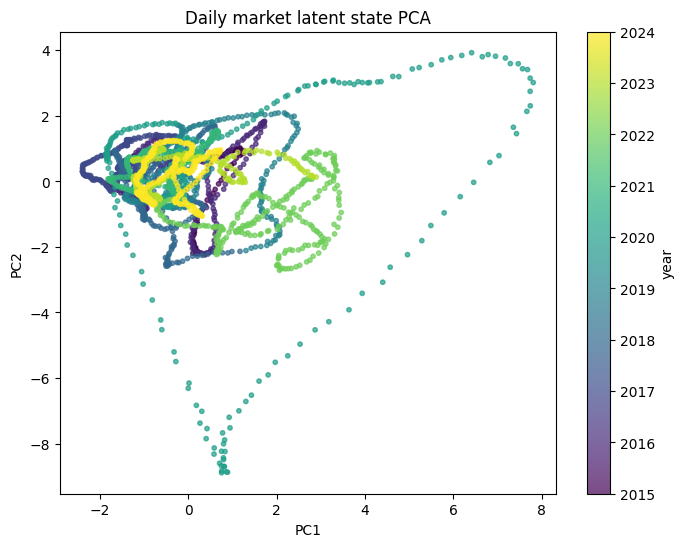

In [7]:
plt.figure(figsize=(8, 6))

sc = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["year"],
    s=10,
    alpha=0.7
)

plt.colorbar(sc, label="year")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Daily market latent state PCA")
plt.show()

In [8]:
N_CLUSTERS = 5

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init="auto"
)

clusters = kmeans.fit_predict(daily_z_scaled)

daily_regimes = daily_z.copy()
daily_regimes["cluster"] = clusters

daily_regimes.head()

/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: Runt

,z_0,z_1,z_2,z_3,z_4,z_5,z_6,z_7,cluster
date,,,,,,,,,
2015-09-21,-0.462186,0.907742,-0.827930,-0.039587,0.893429,0.448083,-0.320765,-0.181429,1
2015-09-22,-0.345922,0.950589,-0.854011,-0.004687,0.870921,0.508142,-0.356737,-0.229827,1
2015-09-23,-0.284812,0.924908,-0.840388,0.047123,0.821326,0.527364,-0.401684,-0.239684,1
2015-09-24,-0.148247,0.930379,-0.883398,0.111333,0.803441,0.587329,-0.437816,-0.239943,1
2015-09-25,-0.061596,0.932906,-0.865143,0.168190,0.712710,0.623032,-0.479264,-0.263772,1


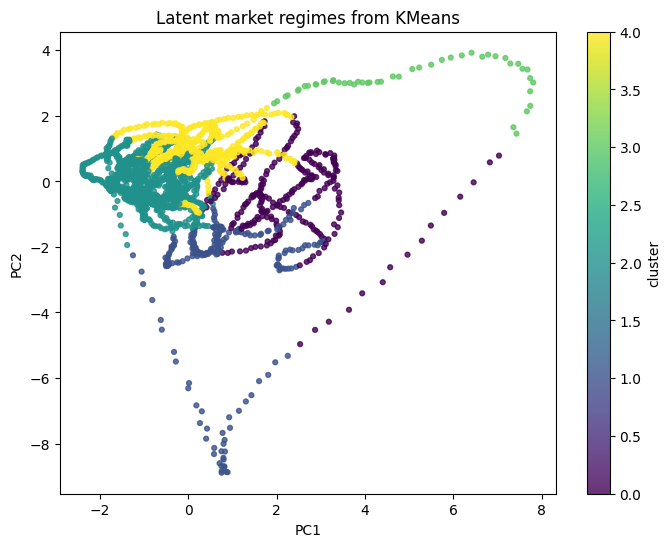

In [9]:
pca_df["cluster"] = clusters

plt.figure(figsize=(8, 6))

sc = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["cluster"],
    s=12,
    alpha=0.8
)

plt.colorbar(sc, label="cluster")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Latent market regimes from KMeans")
plt.show()

In [10]:
market_return = returns.mean(axis=1)
market_return.name = "market_return"

In [11]:
HORIZON = 10

future_market_return = pd.Series(
    0.0,
    index=market_return.index
)

for h in range(1, HORIZON + 1):
    future_market_return += market_return.shift(-h)

future_market_return.name = "future_market_return_10d"

In [12]:
market_vol_20 = market_return.rolling(20).std() * np.sqrt(252)
market_vol_20.name = "market_vol_20"

In [13]:
regime_analysis = daily_regimes[["cluster"]].join(
    [
        market_return,
        future_market_return,
        market_vol_20,
    ],
    how="left"
).dropna()

regime_analysis.head()

,cluster,market_return,future_market_return_10d,market_vol_20
date,,,,
2015-09-21,1.0,0.004612,0.017452,0.331501
2015-09-22,1.0,-0.012498,0.025037,0.297427
2015-09-23,1.0,0.001585,0.027274,0.292742
2015-09-24,1.0,0.000224,0.033600,0.238114
2015-09-25,1.0,-0.000681,0.037008,0.216305


In [14]:
regime_stats = (
    regime_analysis
    .groupby("cluster")
    .agg(
        count=("market_return", "count"),
        mean_daily_return=("market_return", "mean"),
        mean_future_10d_return=("future_market_return_10d", "mean"),
        std_future_10d_return=("future_market_return_10d", "std"),
        mean_vol_20=("market_vol_20", "mean"),
    )
)

regime_stats["future_sharpe_like"] = (
    regime_stats["mean_future_10d_return"]
    / regime_stats["std_future_10d_return"]
)

regime_stats.sort_values("mean_future_10d_return", ascending=False)

,count,mean_daily_return,mean_future_10d_return,std_future_10d_return,mean_vol_20,future_sharpe_like
cluster,,,,,,
3.0,48,0.002303,0.023607,0.019127,0.212179,1.234227
1.0,217,0.001665,0.020813,0.050954,0.344623,0.408473
4.0,530,0.001065,0.010038,0.026610,0.131829,0.377244
2.0,1251,0.000922,0.008657,0.031944,0.138047,0.271001
0.0,280,0.000636,0.006402,0.037899,0.215258,0.168914


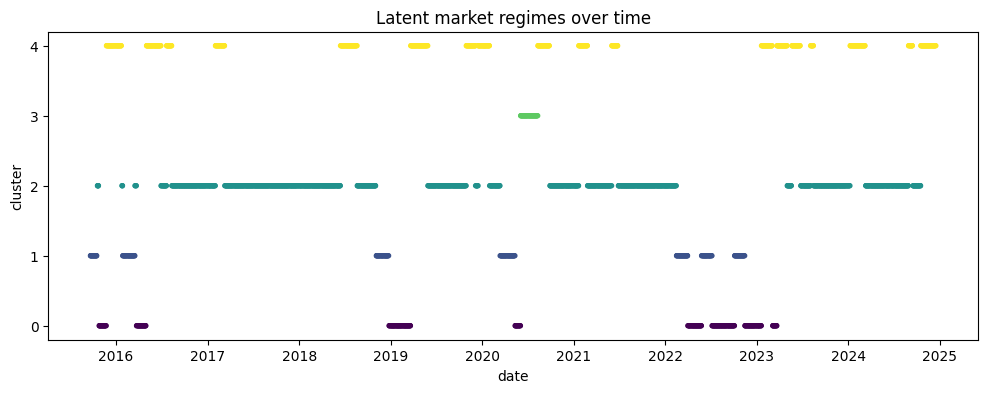

In [15]:
plt.figure(figsize=(12, 4))

plt.scatter(
    regime_analysis.index,
    regime_analysis["cluster"],
    c=regime_analysis["cluster"],
    s=8
)

plt.yticks(range(N_CLUSTERS))
plt.title("Latent market regimes over time")
plt.xlabel("date")
plt.ylabel("cluster")
plt.show()

In [16]:
regime_analysis["year"] = regime_analysis.index.year

year_cluster_counts = pd.crosstab(
    regime_analysis["year"],
    regime_analysis["cluster"],
    normalize="index"
)

year_cluster_counts

cluster,0.0,1.0,2.0,3.0,4.0
year,,,,,
2015,0.291667,0.277778,0.069444,0.000000,0.361111
2016,0.107143,0.134921,0.480159,0.000000,0.277778
2017,0.000000,0.000000,0.896414,0.000000,0.103586
2018,0.015936,0.135458,0.665339,0.000000,0.183267
2019,0.218254,0.000000,0.452381,0.000000,0.329365
2020,0.059289,0.162055,0.379447,0.189723,0.209486
2021,0.000000,0.000000,0.833333,0.000000,0.166667
2022,0.529880,0.350598,0.119522,0.000000,0.000000
2023,0.100000,0.000000,0.544000,0.000000,0.356000


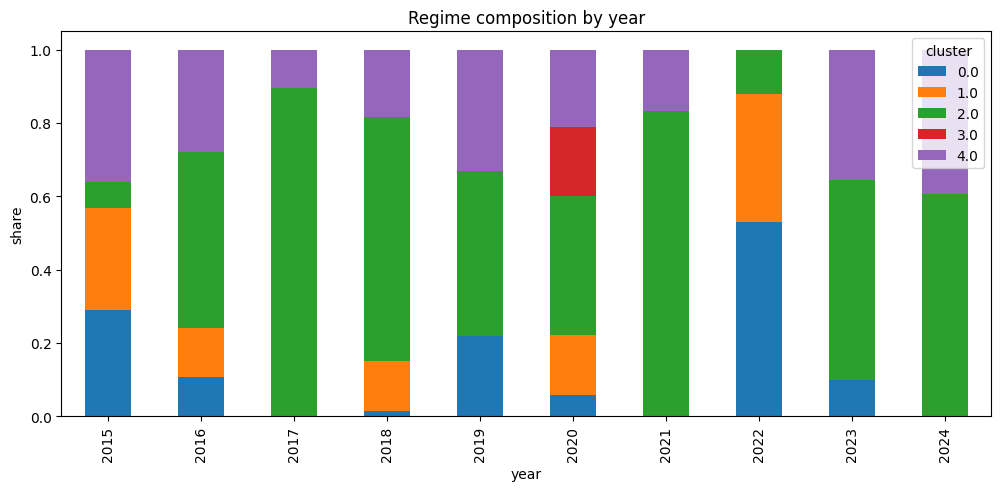

In [17]:
year_cluster_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 5),
    title="Regime composition by year"
)

plt.ylabel("share")
plt.show()

In [18]:
strategy_returns = pd.read_parquet(
    DATA_BACKTESTS / "supervised_vae_backtest_returns.parquet"
)

strategy_returns.index = pd.to_datetime(strategy_returns.index)

strategy_returns.head()

,raw_feature_ridge,supervised_vae_direct,supervised_vae_z_ridge
2022-03-09,-0.001577,-0.004200,-0.004102
2022-03-10,-0.005866,-0.007550,-0.006889
2022-03-11,-0.006915,-0.005700,-0.005965
2022-03-14,0.006271,0.007959,0.007680
2022-03-15,0.010515,0.009140,0.010874


In [19]:
regime_strategy = regime_analysis[["cluster"]].join(
    strategy_returns,
    how="inner"
)

regime_strategy.head()

,cluster,raw_feature_ridge,supervised_vae_direct,supervised_vae_z_ridge
2022-03-09,1.0,-0.001577,-0.004200,-0.004102
2022-03-10,1.0,-0.005866,-0.007550,-0.006889
2022-03-11,1.0,-0.006915,-0.005700,-0.005965
2022-03-14,1.0,0.006271,0.007959,0.007680
2022-03-15,1.0,0.010515,0.009140,0.010874


In [20]:
regime_strategy = regime_analysis[["cluster"]].join(
    strategy_returns,
    how="inner"
)

regime_strategy.head()

,cluster,raw_feature_ridge,supervised_vae_direct,supervised_vae_z_ridge
2022-03-09,1.0,-0.001577,-0.004200,-0.004102
2022-03-10,1.0,-0.005866,-0.007550,-0.006889
2022-03-11,1.0,-0.006915,-0.005700,-0.005965
2022-03-14,1.0,0.006271,0.007959,0.007680
2022-03-15,1.0,0.010515,0.009140,0.010874


In [21]:
strategy_by_regime = (
    regime_strategy
    .groupby("cluster")
    .agg(
        raw_mean=("raw_feature_ridge", "mean"),
        vae_mean=("supervised_vae_direct", "mean"),
        raw_std=("raw_feature_ridge", "std"),
        vae_std=("supervised_vae_direct", "std"),
        count=("supervised_vae_direct", "count"),
    )
)

strategy_by_regime["raw_sharpe_like"] = (
    strategy_by_regime["raw_mean"]
    / strategy_by_regime["raw_std"]
)

strategy_by_regime["vae_sharpe_like"] = (
    strategy_by_regime["vae_mean"]
    / strategy_by_regime["vae_std"]
)

strategy_by_regime["vae_minus_raw"] = (
    strategy_by_regime["vae_mean"]
    - strategy_by_regime["raw_mean"]
)

strategy_by_regime.sort_values("vae_minus_raw", ascending=False)

,raw_mean,vae_mean,raw_std,vae_std,count,raw_sharpe_like,vae_sharpe_like,vae_minus_raw
cluster,,,,,,,,
1.0,0.000017,0.000505,0.005678,0.004467,73,0.003019,0.113102,0.000488
0.0,-0.000096,0.000259,0.005507,0.003878,158,-0.017469,0.066784,0.000355
4.0,0.000346,0.000336,0.003831,0.003269,184,0.090403,0.102788,-0.000010
2.0,0.000463,0.000309,0.003371,0.002768,283,0.137358,0.111611,-0.000154


In [22]:
daily_regimes.to_parquet(
    DATA_BACKTESTS / "latent_market_regimes.parquet"
)

regime_stats.to_csv(
    DATA_BACKTESTS / "latent_market_regime_stats.csv"
)

strategy_by_regime.to_csv(
    DATA_BACKTESTS / "strategy_performance_by_latent_regime.csv"
)

In [23]:
regime_stats.sort_values("mean_future_10d_return", ascending=False)

,count,mean_daily_return,mean_future_10d_return,std_future_10d_return,mean_vol_20,future_sharpe_like
cluster,,,,,,
3.0,48,0.002303,0.023607,0.019127,0.212179,1.234227
1.0,217,0.001665,0.020813,0.050954,0.344623,0.408473
4.0,530,0.001065,0.010038,0.026610,0.131829,0.377244
2.0,1251,0.000922,0.008657,0.031944,0.138047,0.271001
0.0,280,0.000636,0.006402,0.037899,0.215258,0.168914


In [24]:
strategy_by_regime.sort_values("vae_minus_raw", ascending=False)

,raw_mean,vae_mean,raw_std,vae_std,count,raw_sharpe_like,vae_sharpe_like,vae_minus_raw
cluster,,,,,,,,
1.0,0.000017,0.000505,0.005678,0.004467,73,0.003019,0.113102,0.000488
0.0,-0.000096,0.000259,0.005507,0.003878,158,-0.017469,0.066784,0.000355
4.0,0.000346,0.000336,0.003831,0.003269,184,0.090403,0.102788,-0.000010
2.0,0.000463,0.000309,0.003371,0.002768,283,0.137358,0.111611,-0.000154


In [25]:
regime_analysis["year"] = regime_analysis.index.year

dominant_regime = (
    regime_analysis
    .groupby("year")["cluster"]
    .agg(lambda x: x.value_counts().idxmax())
)

dominant_regime

year
2015    4.0
2016    2.0
2017    2.0
2018    2.0
2019    2.0
2020    2.0
2021    2.0
2022    0.0
2023    2.0
2024    2.0
Name: cluster, dtype: float64

In [29]:
walkforward_df = pd.read_csv(
    DATA_BACKTESTS / "walk_forward_validation_results.csv"
)

walkforward_df

,train_start,train_end,test_start,test_end,raw_sharpe,sup_vae_sharpe,raw_total_return,sup_vae_total_return,raw_max_drawdown,sup_vae_max_drawdown,raw_turnover,sup_vae_turnover,sup_best_val_corr,sup_best_epoch
0,2015-01-01,2019-12-31,2020-01-01,2020-12-31,0.957380,2.321453,0.063582,0.134876,-0.073951,-0.026277,0.026614,0.017128,0.090052,0
1,2016-01-01,2020-12-31,2021-01-01,2021-12-31,0.933880,-0.033029,0.047978,-0.001501,-0.035392,-0.052171,0.028307,0.028042,0.215866,1
2,2017-01-01,2021-12-31,2022-01-01,2022-12-31,-1.421151,-0.966250,-0.131020,-0.074112,-0.136634,-0.089253,0.016467,0.023108,0.120277,0
3,2018-01-01,2022-12-31,2023-01-01,2023-12-31,2.720257,2.205198,0.149488,0.092652,-0.028168,-0.028360,0.032800,0.037067,0.026991,9
4,2019-01-01,2023-12-31,2024-01-01,2024-12-31,0.724773,1.582618,0.041617,0.066179,-0.037128,-0.027631,0.019559,0.036088,0.106309,9


In [30]:
walkforward_df.columns

Index(['train_start', 'train_end', 'test_start', 'test_end', 'raw_sharpe',
       'sup_vae_sharpe', 'raw_total_return', 'sup_vae_total_return',
       'raw_max_drawdown', 'sup_vae_max_drawdown', 'raw_turnover',
       'sup_vae_turnover', 'sup_best_val_corr', 'sup_best_epoch'],
      dtype='object')

In [31]:
walkforward_df["test_year"] = pd.to_datetime(
    walkforward_df["test_start"]
).dt.year

walkforward_df[
    [
        "test_year",
        "raw_sharpe",
        "sup_vae_sharpe"
    ]
]

,test_year,raw_sharpe,sup_vae_sharpe
0,2020,0.957380,2.321453
1,2021,0.933880,-0.033029
2,2022,-1.421151,-0.966250
3,2023,2.720257,2.205198
4,2024,0.724773,1.582618


In [32]:
dominant_regime = (
    regime_analysis
    .groupby("year")["cluster"]
    .agg(lambda x: x.value_counts().idxmax())
    .rename("dominant_cluster")
)

dominant_regime

year
2015    4.0
2016    2.0
2017    2.0
2018    2.0
2019    2.0
2020    2.0
2021    2.0
2022    0.0
2023    2.0
2024    2.0
Name: dominant_cluster, dtype: float64

In [33]:
comparison = walkforward_df.merge(
    dominant_regime.reset_index(),
    left_on="test_year",
    right_on="year"
)

comparison[
    [
        "test_year",
        "dominant_cluster",
        "raw_sharpe",
        "sup_vae_sharpe"
    ]
]

,test_year,dominant_cluster,raw_sharpe,sup_vae_sharpe
0,2020,2.0,0.957380,2.321453
1,2021,2.0,0.933880,-0.033029
2,2022,0.0,-1.421151,-0.966250
3,2023,2.0,2.720257,2.205198
4,2024,2.0,0.724773,1.582618


In [34]:
year_cluster_shares = pd.crosstab(
    regime_analysis["year"],
    regime_analysis["cluster"],
    normalize="index"
)

year_cluster_shares

cluster,0.0,1.0,2.0,3.0,4.0
year,,,,,
2015,0.291667,0.277778,0.069444,0.000000,0.361111
2016,0.107143,0.134921,0.480159,0.000000,0.277778
2017,0.000000,0.000000,0.896414,0.000000,0.103586
2018,0.015936,0.135458,0.665339,0.000000,0.183267
2019,0.218254,0.000000,0.452381,0.000000,0.329365
2020,0.059289,0.162055,0.379447,0.189723,0.209486
2021,0.000000,0.000000,0.833333,0.000000,0.166667
2022,0.529880,0.350598,0.119522,0.000000,0.000000
2023,0.100000,0.000000,0.544000,0.000000,0.356000


In [35]:
comparison2 = walkforward_df.copy()

comparison2["test_year"] = pd.to_datetime(
    comparison2["test_start"]
).dt.year

comparison2["vae_minus_raw_sharpe"] = (
    comparison2["sup_vae_sharpe"]
    - comparison2["raw_sharpe"]
)

regime_perf = comparison2.merge(
    year_cluster_shares.reset_index(),
    left_on="test_year",
    right_on="year",
    how="left"
)

regime_perf[
    [
        "test_year",
        "vae_minus_raw_sharpe",
        0.0, 1.0, 2.0, 3.0, 4.0
    ]
]

,test_year,vae_minus_raw_sharpe,0.0,1.0,2.0,3.0,4.0
0,2020,1.364072,0.059289,0.162055,0.379447,0.189723,0.209486
1,2021,-0.966909,0.000000,0.000000,0.833333,0.000000,0.166667
2,2022,0.454901,0.529880,0.350598,0.119522,0.000000,0.000000
3,2023,-0.515059,0.100000,0.000000,0.544000,0.000000,0.356000
4,2024,0.857846,0.000000,0.000000,0.607438,0.000000,0.392562
